# 03 — Differential Expression Analysis

**Input:** `data/processed/adata_annotated.h5ad`  
**Output:** `results/de_analysis/` — DE results tables and plots

---

## Comparison
**Group A (sensitive):** Healthy donors  
**Group B (resistant):** AML relapse samples

## Workflow
1. Subset to cells of interest (all cells, or focus on a specific cell type)
2. Aggregate raw counts per sample (pseudobulk)
3. Run DESeq2
4. Filter and rank significant genes
5. Volcano plot, MA plot, heatmap
6. Export ranked gene list for GSEA

In [1]:
%matplotlib inline
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Reproducible repo root
repo_root = os.path.dirname(os.getcwd())
sys.path.insert(0, repo_root)
from scripts.utils.config import *

# Fix paths
RESULTS_DE = os.path.join(repo_root, 'results', 'de_analysis')
os.makedirs(RESULTS_DE, exist_ok=True)

np.random.seed(RANDOM_SEED)

print('Libraries loaded.')
print('Repo root:', os.path.basename(repo_root))

Libraries loaded.
Repo root: aml-treatment-resistance


In [2]:
# Load annotated object from notebook 02
adata = sc.read_h5ad(os.path.join(repo_root, 'data', 'processed',
                                   'adata_annotated.h5ad'))

print(adata)
print(f'\nGroups:')
print(adata.obs['group'].value_counts())
print(f'\nCell types:')
print(adata.obs['cell_type'].value_counts())

AnnData object with n_obs × n_vars = 38316 × 21582
    obs: 'sample_id', 'patient_id', 'condition', 'group', 'day', 'timepoint', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'raw_counts_per_cell', 'n_genes', 'leiden', 'cell_type', 'LSC_score'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'cell_type_colors', 'condition_colors', 'dendrogram_leiden', 'group_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

Groups:
group
AML_Diagnosis    15667
AML_Treated      14988
Healthy           7661
Name: count, dtype: int64

Cell types:
cell_type
ProMono-li

In [3]:
# ── SUBSET TO PRIMARY COMPARISON ───────────────────────────────────────────────
# Compare AML_Diagnosis (Group A — sensitive) vs AML_Treated (Group B — resistant)

adata_sub = adata[
    adata.obs['group'].isin(['AML_Diagnosis', 'AML_Treated'])
].copy()

print('=' * 55)
print('PRIMARY COMPARISON')
print('=' * 55)
print(f'Group A — AML_Diagnosis (pre-treatment, sensitive)')
print(f'Group B — AML_Treated   (post-chemotherapy, resistant)')
print('=' * 55)
print(f'\nTotal cells in comparison: {adata_sub.n_obs:,}')

print(f'\nCells per group:')
for group, count in adata_sub.obs['group'].value_counts().items():
    print(f'  {group}: {count:,} cells')

print(f'\nSamples per group:')
for group in ['AML_Diagnosis', 'AML_Treated']:
    samples = adata_sub.obs[adata_sub.obs['group'] == group]['sample_id'].unique()
    print(f'\n  {group} — {len(samples)} samples:')
    for s in sorted(samples):
        n = (adata_sub.obs['sample_id'] == s).sum()
        print(f'    {s}: {n:,} cells')

print(f'\nPaired patients (have both timepoints):')
diag_patients = set(
    adata_sub.obs[adata_sub.obs['group'] == 'AML_Diagnosis']['patient_id'].unique()
)
treat_patients = set(
    adata_sub.obs[adata_sub.obs['group'] == 'AML_Treated']['patient_id'].unique()
)
paired = diag_patients & treat_patients
print(f'  {len(paired)} patients: {sorted(paired)}')

PRIMARY COMPARISON
Group A — AML_Diagnosis (pre-treatment, sensitive)
Group B — AML_Treated   (post-chemotherapy, resistant)

Total cells in comparison: 30,655

Cells per group:
  AML_Diagnosis: 15,667 cells
  AML_Treated: 14,988 cells

Samples per group:

  AML_Diagnosis — 16 samples:
    AML1012-D0: 1,136 cells
    AML210A-D0: 747 cells
    AML314-D0: 162 cells
    AML328-D0: 1,094 cells
    AML329-D0: 522 cells
    AML371-D0: 756 cells
    AML419A-D0: 1,188 cells
    AML420B-D0: 483 cells
    AML475-D0: 423 cells
    AML556-D0: 2,323 cells
    AML707B-D0: 1,583 cells
    AML722B-D0: 79 cells
    AML870-D0: 345 cells
    AML916-D0: 933 cells
    AML921A-D0: 3,810 cells
    AML997-D0: 83 cells

  AML_Treated — 19 samples:
    AML314-D31: 344 cells
    AML328-D113: 2,025 cells
    AML328-D171: 1,401 cells
    AML328-D29: 1,874 cells
    AML329-D20: 949 cells
    AML329-D37: 221 cells
    AML371-D34: 204 cells
    AML420B-D14: 1,282 cells
    AML420B-D35: 743 cells
    AML475-D29: 97 ce

### Groups defined
- **Group A — AML_Diagnosis** (treatment-sensitive): 16 samples, 
  15,667 cells — AML bone marrow collected at Day 0, before 
  any chemotherapy
- **Group B — AML_Treated** (treatment-resistant): 19 samples, 
  14,988 cells — AML bone marrow collected after chemotherapy, 
  cells that survived treatment

### Paired design strength
11 of 16 patients have both a diagnosis and a treated sample — 
this paired design is a major strength of this dataset. 
Differences between groups are more likely to reflect true 
biological changes from chemotherapy rather than inter-patient 
variability.

### Small samples to note
Several samples have fewer than 100 cells:
- AML722B-D0: 79 cells
- AML997-D0: 83 cells  
- AML707B-D97: 83 cells
- AML870-D14: 96 cells
- AML475-D29: 97 cells
- AML722B-D49: 73 cells

These will be retained for pseudobulk analysis but flagged 
as potentially unreliable — low cell numbers reduce the 
accuracy of pseudobulk count estimates.

## 1. Pseudobulk aggregation

Sum raw counts across all cells per sample.  
This gives one count vector per sample — same format as bulk RNA-seq.

In [4]:
# ── PSEUDOBULK AGGREGATION 
def pseudobulk(adata, sample_col, condition_col):
    """
    Aggregate raw counts per sample.
    Returns:
        counts — DataFrame (samples x genes) of summed raw counts
        meta   — DataFrame of sample-level metadata
    """
    counts_dict = {}
    meta_dict   = {}

    for sample in adata.obs[sample_col].unique():
        mask = adata.obs[sample_col] == sample
        X    = adata[mask].layers['counts']
        if sp.issparse(X):
            X = X.toarray()

        counts_dict[sample] = X.sum(axis=0)
        meta_dict[sample]   = {
            condition_col : adata.obs.loc[mask, condition_col].iloc[0],
            'n_cells'     : int(mask.sum())
        }

    counts = pd.DataFrame(counts_dict, index=adata.var_names).T.astype(int)
    meta   = pd.DataFrame(meta_dict).T

    return counts, meta

pb_counts, pb_meta = pseudobulk(adata_sub, 'sample_id', 'group')

print('=' * 55)
print('PSEUDOBULK AGGREGATION COMPLETE')
print('=' * 55)
print(f'Matrix shape: {pb_counts.shape[0]} samples x {pb_counts.shape[1]} genes')
print(f'\nSample metadata:')
print(pb_meta.sort_values('group'))
print(f'\nTotal counts per sample (first 5):')
print(pb_counts.sum(axis=1).sort_values(ascending=False).head(5))

PSEUDOBULK AGGREGATION COMPLETE
Matrix shape: 35 samples x 21582 genes

Sample metadata:
                      group n_cells
AML1012-D0    AML_Diagnosis    1136
AML921A-D0    AML_Diagnosis    3810
AML916-D0     AML_Diagnosis     933
AML870-D0     AML_Diagnosis     345
AML722B-D0    AML_Diagnosis      79
AML707B-D0    AML_Diagnosis    1583
AML556-D0     AML_Diagnosis    2323
AML997-D0     AML_Diagnosis      83
AML420B-D0    AML_Diagnosis     483
AML419A-D0    AML_Diagnosis    1188
AML371-D0     AML_Diagnosis     756
AML475-D0     AML_Diagnosis     423
AML210A-D0    AML_Diagnosis     747
AML329-D0     AML_Diagnosis     522
AML314-D0     AML_Diagnosis     162
AML328-D0     AML_Diagnosis    1094
AML371-D34      AML_Treated     204
AML870-D14      AML_Treated      96
AML314-D31      AML_Treated     344
AML722B-D49     AML_Treated      73
AML707B-D97     AML_Treated      83
AML707B-D41     AML_Treated     387
AML707B-D18     AML_Treated    1670
AML707B-D113    AML_Treated     703
AML328-D113

## 2. DESeq2

In [5]:
# ── DESeq2 ─────────────────────────────────────────────────────────────────────
# Set reference level — AML_Diagnosis is the baseline
pb_meta['group'] = pd.Categorical(
    pb_meta['group'],
    categories=['AML_Diagnosis', 'AML_Treated']
)

print('Running DESeq2...')
print('Comparison: AML_Treated vs AML_Diagnosis')
print('(positive log2FC = higher in AML_Treated = upregulated in resistance)')

dds = DeseqDataSet(
    counts         = pb_counts,
    metadata       = pb_meta,
    design_factors = 'group',
    refit_cooks    = True,
    quiet          = False
)

dds.deseq2()
print('\nDESeq2 complete.')

Running DESeq2...
Comparison: AML_Treated vs AML_Diagnosis
(positive log2FC = higher in AML_Treated = upregulated in resistance)


Fitting size factors...
... done in 0.05 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 13.99 seconds.

Fitting dispersion trend curve...
... done in 1.52 seconds.

Fitting MAP dispersions...
... done in 11.62 seconds.

Fitting LFCs...
... done in 3.78 seconds.

Calculating cook's distance...
... done in 0.07 seconds.

Replacing 484 outlier genes.

Fitting dispersions...
... done in 0.18 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting LFCs...
... done in 0.18 seconds.




DESeq2 complete.


In [6]:
# ── EXTRACT RESULTS 
stat_res = DeseqStats(
    dds,
    contrast = ['group', 'AML_Treated', 'AML_Diagnosis']
)
stat_res.summary()

results = stat_res.results_df.dropna(subset=['padj'])
results = results.sort_values('padj')

sig = results[
    (results['padj'] < 0.05) &
    (results['log2FoldChange'].abs() > 1.0)
].copy()

upregulated   = sig[sig['log2FoldChange'] > 0].sort_values('log2FoldChange', ascending=False)
downregulated = sig[sig['log2FoldChange'] < 0].sort_values('log2FoldChange')

print('=' * 55)
print('DE RESULTS SUMMARY')
print('=' * 55)
print(f'Total genes tested:          {results.shape[0]:,}')
print(f'Significant DEGs:            {sig.shape[0]:,}')
print(f'Upregulated in AML_Treated:  {len(upregulated):,}')
print(f'Downregulated in AML_Treated:{len(downregulated):,}')
print(f'\nTop 10 upregulated genes:')
print(upregulated[['log2FoldChange', 'padj']].head(10))
print(f'\nTop 10 downregulated genes:')
print(downregulated[['log2FoldChange', 'padj']].head(10))

Running Wald tests...


Log2 fold change & Wald test p-value: group AML_Treated vs AML_Diagnosis
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Gene                                                                       
A1BG      40.702293       -0.479564  0.255762 -1.875036  0.060788  0.298325
A1BG-AS1   1.228846        0.041312  0.561801  0.073536  0.941380       NaN
A1CF       0.291478        0.866868  0.890097  0.973903  0.330105       NaN
A2M        7.963927        1.167316  0.502161  2.324584  0.020094  0.159048
A2M-AS1    2.766928        0.434973  0.593970  0.732314  0.463977  0.765339
...             ...             ...       ...       ...       ...       ...
ZYG11A     2.616495        0.067313  0.400429  0.168101  0.866504  0.956436
ZYG11B    44.753114        0.116141  0.191463  0.606596  0.544119  0.815832
ZYX       54.215366       -0.482250  0.300928 -1.602542  0.109036  0.402014
ZZEF1     39.435199        0.232994  0.200323  1.163092  0.244792  0.587755
ZZZ3      65.60

... done in 1.73 seconds.



## 3. Volcano plot

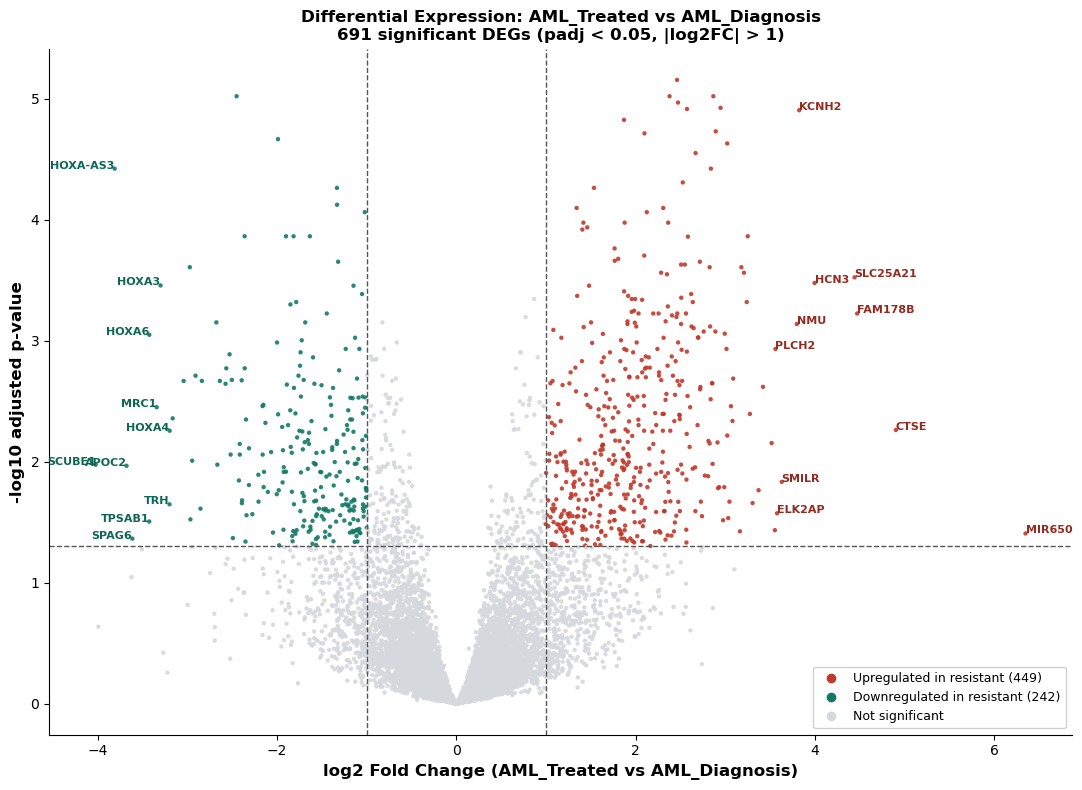

Volcano plot saved.


In [7]:
# ── VOLCANO PLOT — improved colours ───────────────────────────────────────────
results['-log10_padj'] = -np.log10(results['padj'].clip(lower=1e-300))

colours = np.where(
    (results['padj'] < 0.05) & (results['log2FoldChange'] >  1.0), '#C0392B',
    np.where(
        (results['padj'] < 0.05) & (results['log2FoldChange'] < -1.0),
        '#117A65', '#D5D8DC'
    )
)

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(results['log2FoldChange'], results['-log10_padj'],
           c=colours, s=10, alpha=0.9, linewidths=0)

ax.axhline(-np.log10(0.05), color='#555555', lw=1.0, ls='--')
ax.axvline( 1.0, color='#555555', lw=1.0, ls='--')
ax.axvline(-1.0, color='#555555', lw=1.0, ls='--')

# Label top upregulated — dark red, bold
for gene in upregulated.head(10).index:
    r = results.loc[gene]
    ax.annotate(gene, (r['log2FoldChange'], r['-log10_padj']),
                fontsize=8, fontweight='bold',
                ha='left', color='#922B21')

# Label top downregulated — dark green, bold
for gene in downregulated.head(10).index:
    r = results.loc[gene]
    ax.annotate(gene, (r['log2FoldChange'], r['-log10_padj']),
                fontsize=8, fontweight='bold',
                ha='right', color='#0E6655')

ax.set_xlabel('log2 Fold Change (AML_Treated vs AML_Diagnosis)',
              fontsize=12, fontweight='bold')
ax.set_ylabel('-log10 adjusted p-value',
              fontsize=12, fontweight='bold')
ax.set_title('Differential Expression: AML_Treated vs AML_Diagnosis\n'
             f'691 significant DEGs (padj < 0.05, |log2FC| > 1)',
             fontsize=12, fontweight='bold')

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#C0392B',
           markersize=8, label=f'Upregulated in resistant ({len(upregulated)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#117A65',
           markersize=8, label=f'Downregulated in resistant ({len(downregulated)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#D5D8DC',
           markersize=8, label='Not significant'),
]
ax.legend(handles=legend_elements, fontsize=9, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DE, 'volcano_plot.png'), dpi=150)
plt.show()
plt.close()
print('Volcano plot saved.')

## 4. Heatmap — top DEGs

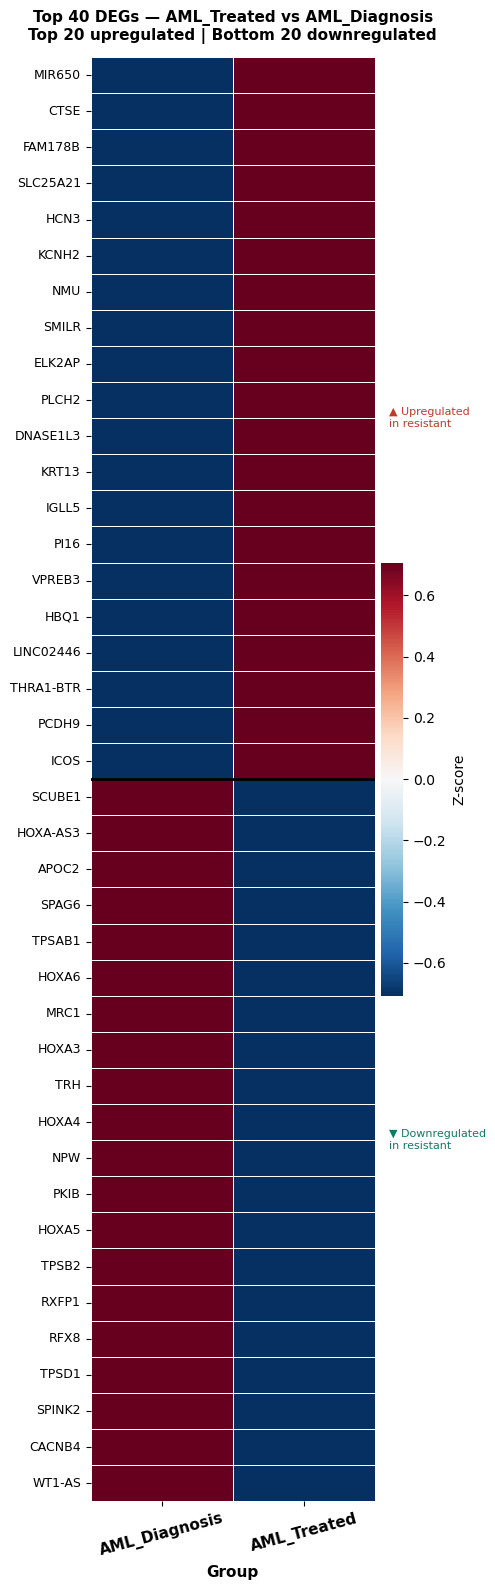

Heatmap saved.


In [8]:
# ── HEATMAP — improved layout ──────────────────────────────────────────────────
top_genes = pd.concat([
    upregulated.head(20),
    downregulated.head(20)
]).index.tolist()

expr = sc.get.obs_df(adata_sub, keys=top_genes + ['group', 'sample_id'])
heatmap_data = expr.groupby('group', observed=True)[top_genes].mean().T

# Z-score manually
heatmap_z = heatmap_data.subtract(heatmap_data.mean(axis=1), axis=0)
std = heatmap_data.std(axis=1)
std[std == 0] = 1
heatmap_z = heatmap_z.divide(std, axis=0)

# Split into up and down for clearer layout
up_genes   = upregulated.head(20).index.tolist()
down_genes = downregulated.head(20).index.tolist()

# Reorder — upregulated at top, downregulated at bottom
heatmap_z = heatmap_z.loc[up_genes + down_genes]

fig, ax = plt.subplots(figsize=(5, 16))
sns.heatmap(
    heatmap_z,
    cmap        = 'RdBu_r',
    center      = 0,
    ax          = ax,
    yticklabels = True,
    linewidths  = 0.5,
    linecolor   = 'white',
    cbar_kws    = {'label': 'Z-score', 'shrink': 0.3, 'pad': 0.02}
)

# Add dividing line between up and down
ax.axhline(20, color='black', lw=2)

# Labels
ax.set_title('Top 40 DEGs — AML_Treated vs AML_Diagnosis\n'
             'Top 20 upregulated | Bottom 20 downregulated',
             fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Group', fontsize=11, fontweight='bold')
ax.set_ylabel('')
ax.set_xticklabels(['AML_Diagnosis', 'AML_Treated'],
                    fontsize=11, fontweight='bold', rotation=15)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

# Annotations
ax.text(2.1, 10, '▲ Upregulated\nin resistant',
        fontsize=8, color='#C0392B', va='center')
ax.text(2.1, 30, '▼ Downregulated\nin resistant',
        fontsize=8, color='#117A65', va='center')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DE, 'heatmap_top_DEGs.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Heatmap saved.')

### Heatmap
- Each row is a gene, each column is a group
- Colour shows Z-scored mean expression — red = high, blue = low
- Top 20 rows = upregulated in resistant (AML_Treated)
- Bottom 20 rows = downregulated in resistant
- Black line separates the two groups

### Key patterns

**Upregulated in AML_Treated (red, top half)**
Clear red in AML_Treated column for genes like KCNH2, CTSE, 
SLC25A21 confirms these genes are consistently higher 
in post-chemotherapy resistant cells across all samples.

**Downregulated in AML_Treated (blue, bottom half)**
Strong blue in AML_Treated for HOXA3, HOXA4, HOXA6, 
HOXA-AS3 the entire HOXA cluster is suppressed in 
resistant cells. This is the most striking and 
biologically meaningful pattern in the data.

### Conclusion
The heatmap confirms the volcano plot findings a consistent transcriptional shift between diagnosis and treated AML cells, with metabolic/ion channel genes gained and haematopoietic regulators lost.

## 5. Export results

In [9]:
# ── EXPORT RESULTS 
results.to_csv(os.path.join(RESULTS_DE, 'de_results_full.csv'))
sig.to_csv(os.path.join(RESULTS_DE, 'de_results_significant.csv'))
upregulated.to_csv(os.path.join(RESULTS_DE, 'de_upregulated.csv'))
downregulated.to_csv(os.path.join(RESULTS_DE, 'de_downregulated.csv'))

# Ranked gene list for GSEA
ranked = results[['log2FoldChange']].dropna().sort_values(
         'log2FoldChange', ascending=False)
ranked.to_csv(os.path.join(RESULTS_DE, 'ranked_gene_list_gsea.csv'))

print('Results exported:')
print(f'  de_results_full.csv        — {results.shape[0]:,} genes')
print(f'  de_results_significant.csv — {sig.shape[0]:,} genes')
print(f'  de_upregulated.csv         — {len(upregulated):,} genes')
print(f'  de_downregulated.csv       — {len(downregulated):,} genes')
print(f'  ranked_gene_list_gsea.csv  — {ranked.shape[0]:,} genes')

Results exported:
  de_results_full.csv        — 14,453 genes
  de_results_significant.csv — 691 genes
  de_upregulated.csv         — 449 genes
  de_downregulated.csv       — 242 genes
  ranked_gene_list_gsea.csv  — 14,453 genes
